In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import statistics
import sys

sys.path.append(os.path.abspath(os.path.join('..')))
import src.correlation_tools as ct
import src.subvolume_utils as su
import src.plotting as pg

from dotenv import load_dotenv
load_dotenv()

data_dir = os.getenv('data_dir')
g_base = os.getenv('galaxy_base')
h_base = os.getenv('halo_base')
galaxies = f"{g_base}base_c000_ph000/z0p300/model_hod000000/gals.fit"
halos = f"{h_base}base_c000_ph000/z0p300/halos_3e+12.fit"
sub_ = 4

## figuring out avg number of halos in each subvol: avg = 1831

In [ ]:
average_lengths = []
for i in range(25):
    halos = f"{h_base}base_c000_ph{i:03d}/z0p300/halos_3e+12.fit"
    hx, hy, hz, hsections, hbins = su.subvolume_calc(fname = halos, sub_ = sub_, var = 'mass', min_= 10**14)
    length = []
    for i in range (sub_**3):
        idx = hbins[hsections[i]: hsections[i+1]]
        l = len(hx[idx])
        length.append(l)
    average_lengths.append(np.mean(length))

# 1831.08625
average_halos = np.mean(average_lengths)
print(average_halos)

1831.08625


# Visualizing: no comparison

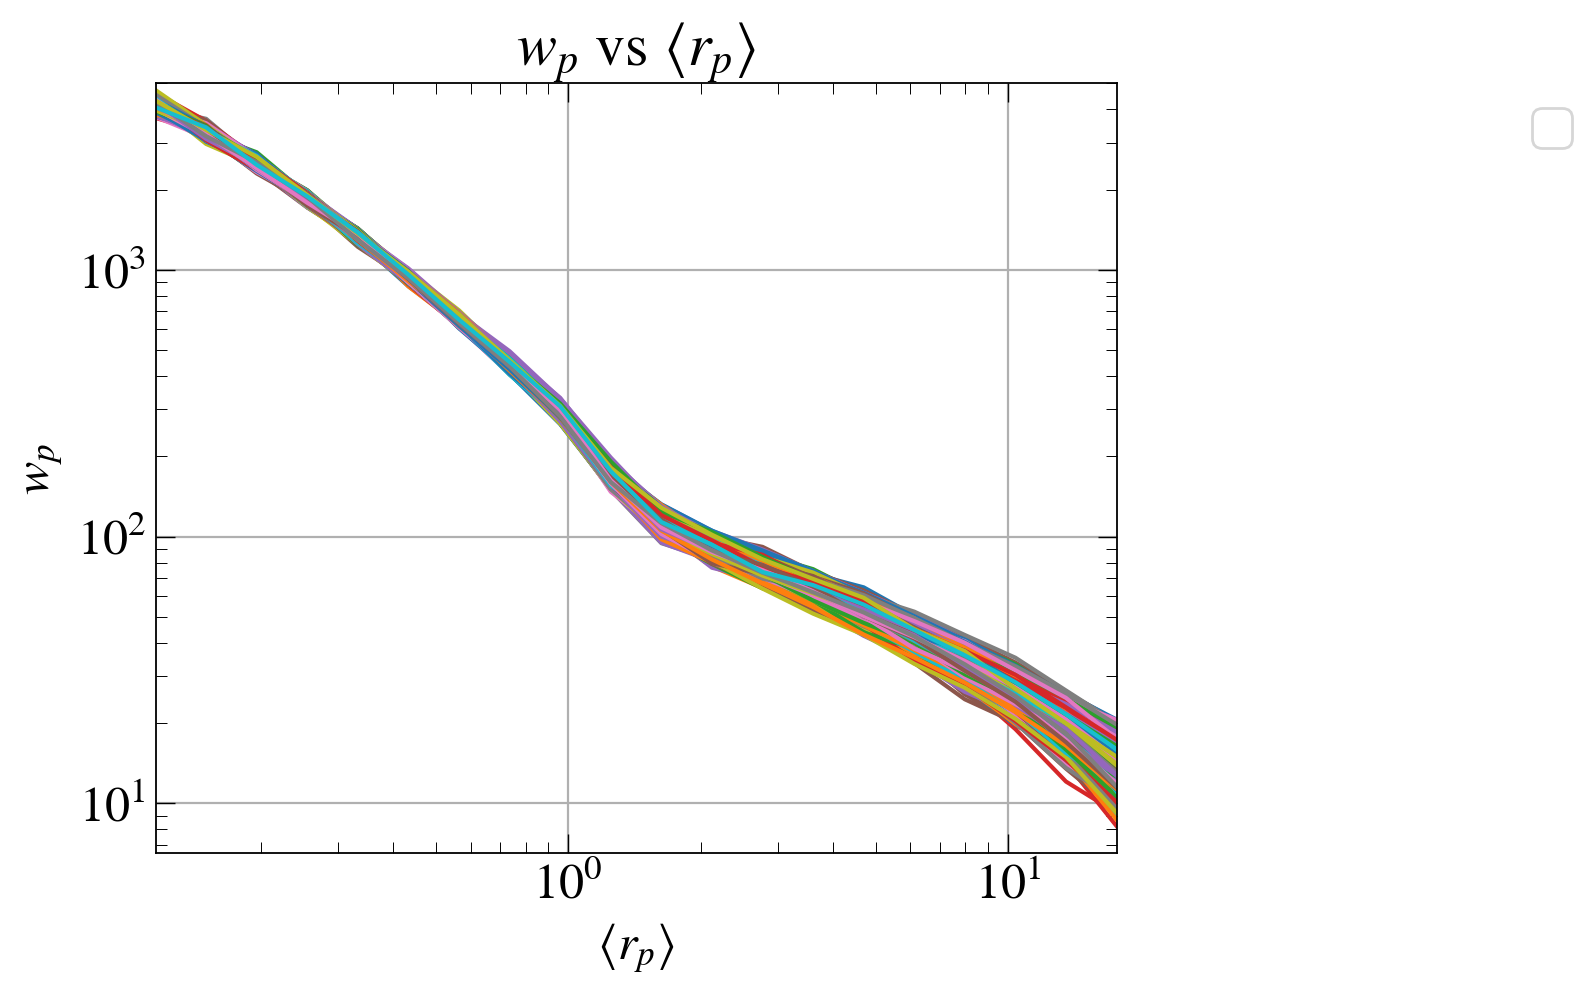

In [3]:
file = f"{data_dir}wp_counts_ph000.npz"
data = np.load(file)
all_wp_counts = data['wp_']
all_rp_counts = data['rp_avg']
for i in range (1, 25):
    file = f"{data_dir}wp_counts_ph{i:03d}.npz"
    data = np.load(file)
    all_wp_counts = np.concatenate((all_wp_counts, data['wp_']))
    all_rp_counts = np.concatenate((all_rp_counts, data['rp_avg']))
rp_temp, wp_temp, stdev_temp = ct.error_data(all_rp_counts, all_wp_counts)
pg.plot_results(all_rp_counts, all_wp_counts, y_max= 5000, y_min = 6.5)

14.128022053663898 4207.923326554504


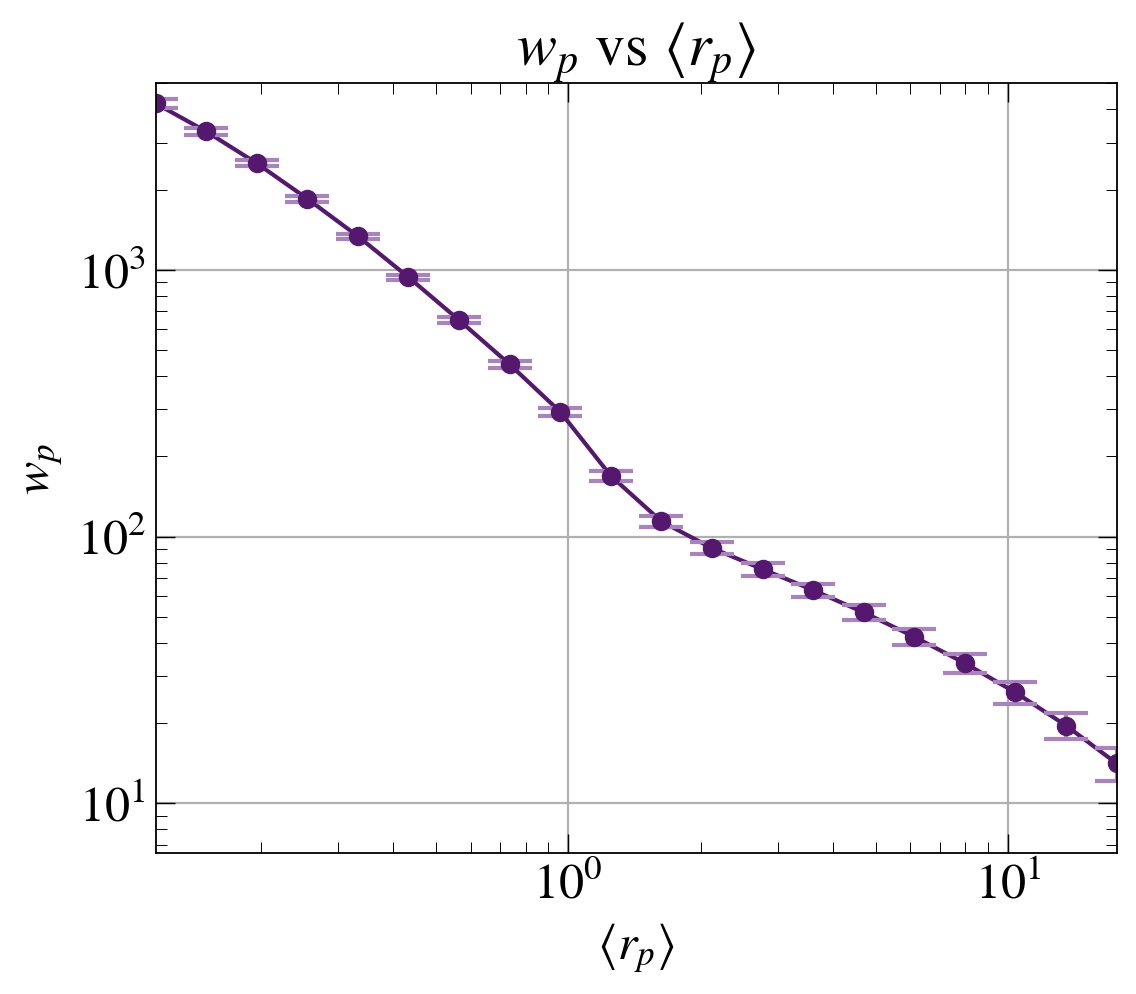

In [5]:
rp_mean, wp_mean, stdev_ = ct.error_data(all_rp_counts, all_wp_counts)
pg.wp_vs_rpavg(rp_mean, wp_mean, stdev_, y_max=5000, y_min = 6.5, legend = 'counts')
plt.show()

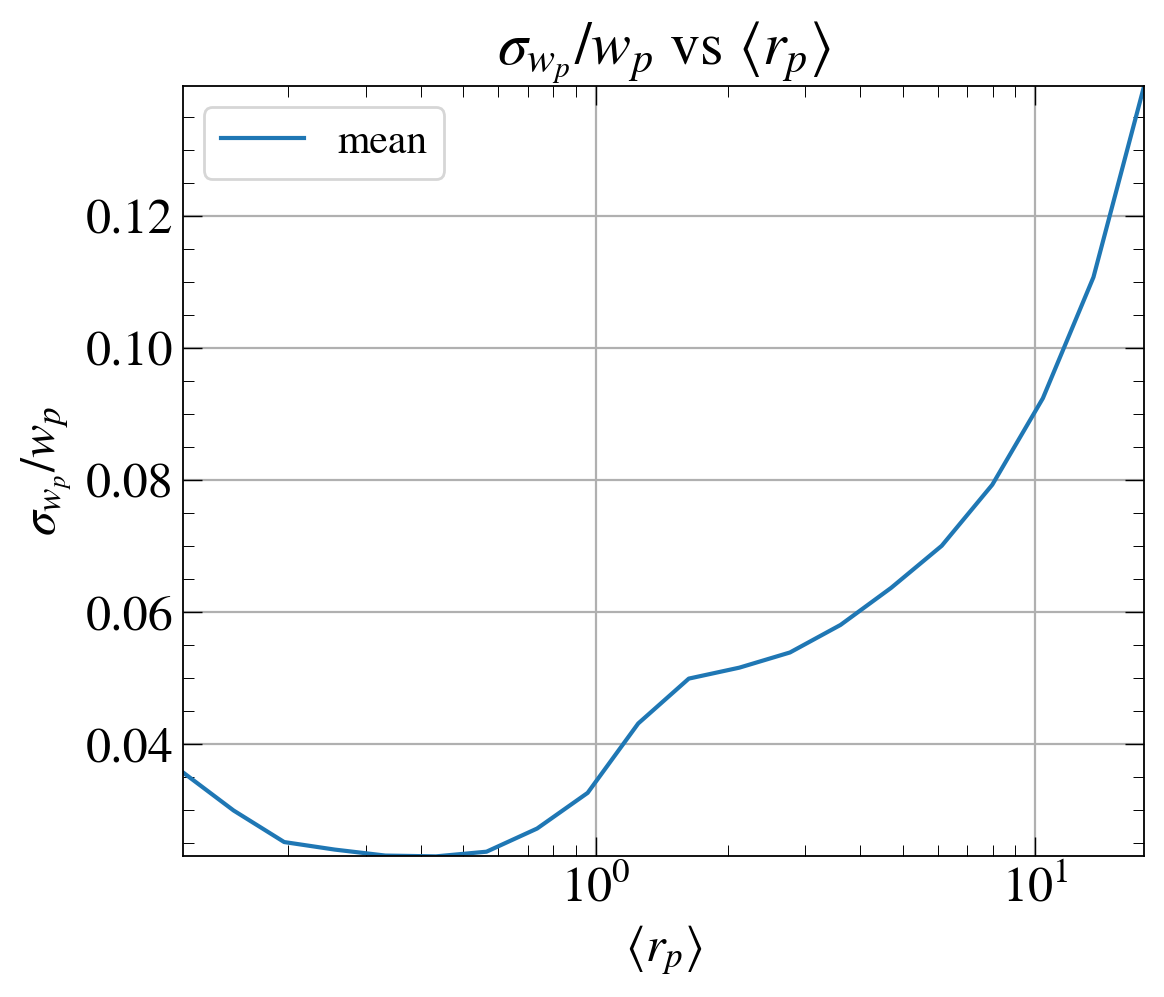

In [8]:
frac_err = pg.get_frac_err(stdev_, wp_mean)
pg.plot_frac_err([rp_mean], [frac_err], labels = ['mean'])
plt.show()

# Visualizing w/ comp

In [10]:
file = f"{data_dir}wp_ph000.npz"
data = np.load(file)
all_wp_thresh = data['wp_']
all_rp_thresh = data['rp_avg']
for i in range (1, 25):
    file = f"{data_dir}wp_ph{i:03d}.npz"
    data = np.load(file)
    all_wp_thresh = np.concatenate((all_wp_thresh, data['wp_']))
    all_rp_thresh = np.concatenate((all_rp_thresh, data['rp_avg']))
rp_thresh, wp_thresh, stdev_thresh = ct.error_data(all_rp_thresh, all_wp_thresh)

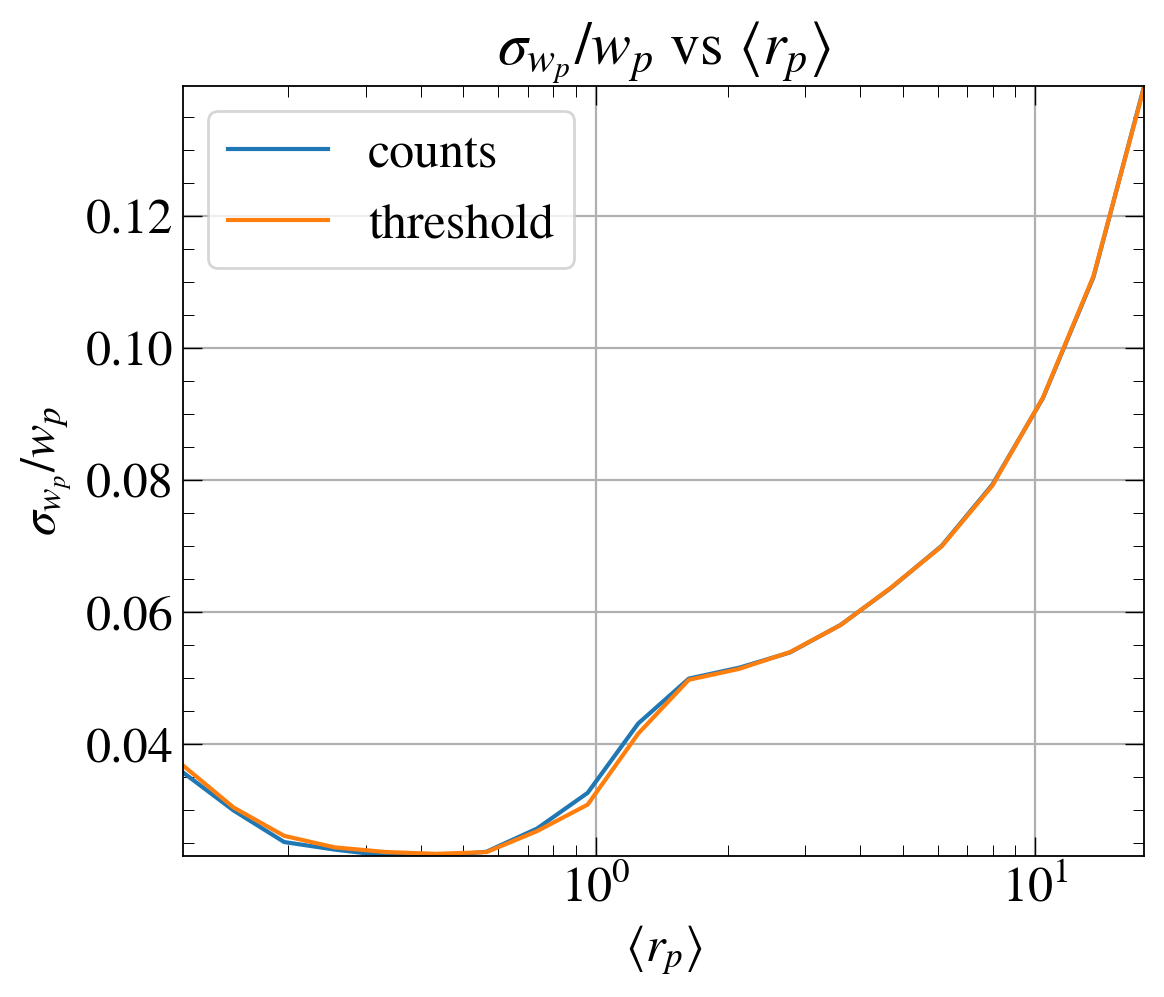

In [12]:
frac_err_thresh = pg.get_frac_err(stdev_thresh, wp_thresh)
pg.plot_frac_err([rp_mean, rp_thresh], [frac_err, frac_err_thresh], labels = ['counts', 'threshold'])
plt.legend()

14.128022053663898 4207.923326554504
14.128022053663898 4207.923326554504


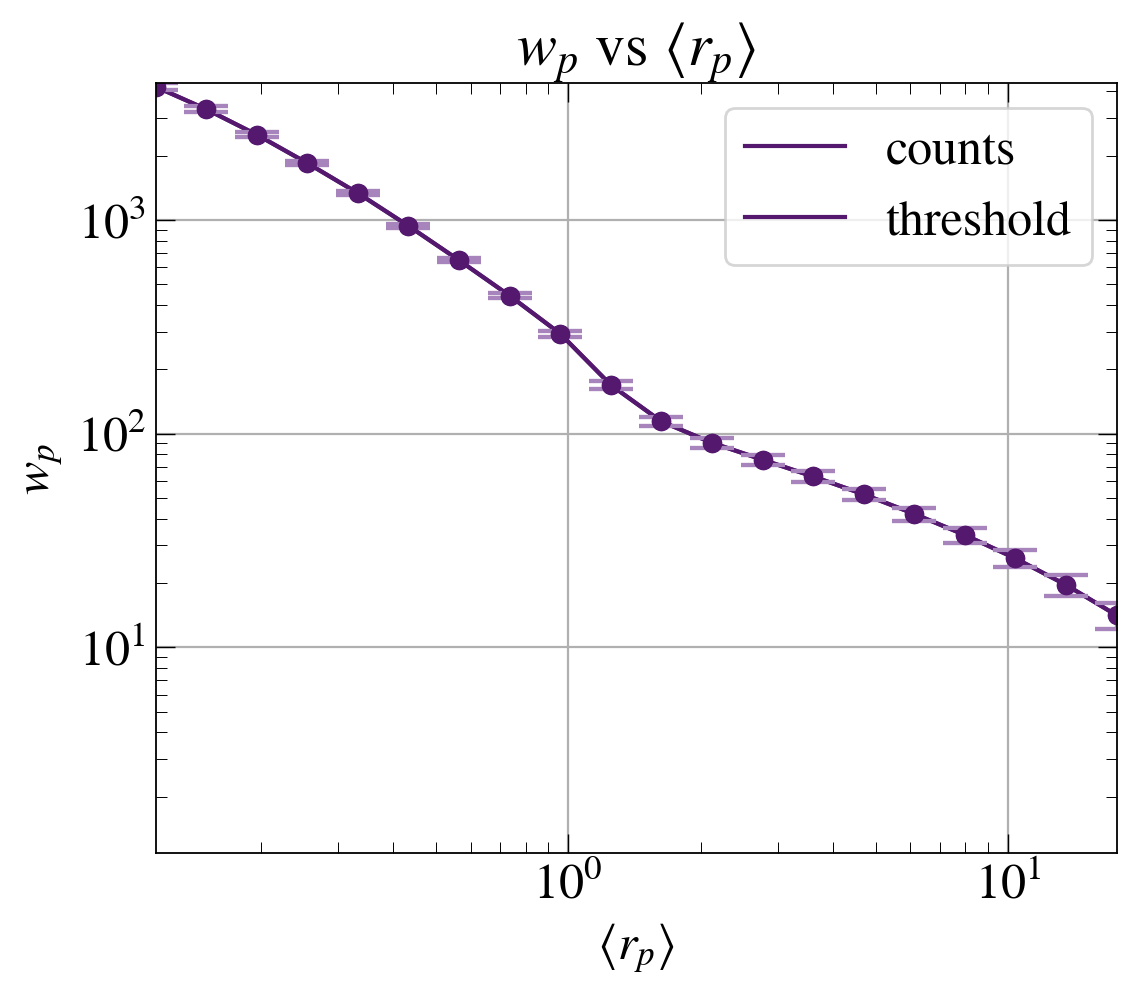

In [13]:
pg.wp_vs_rpavg(rp_mean, wp_mean, stdev_, legend = 'counts')
pg.wp_vs_rpavg(rp_thresh, wp_mean, stdev_thresh, legend = 'threshold')
plt.legend()
plt.show()

4207.923326554504 4207.27006848533 1.0001552688699655
3302.7072329996577 3303.4832466691364 0.9997650922945466
2509.1190434721693 2510.07175144473 0.9996204459207142
1847.234924305463 1847.2054063725348 1.0000159797783323
1336.341855784286 1336.1473816681548 1.00014554840192
938.5665456842145 938.8505293116501 0.9996975198728983
648.1710311429277 648.3601414151404 0.9997083252653379
442.4246961157825 442.43411941778305 0.9999787012312411
293.7155140684528 293.80317156390726 0.9997016455098567
169.0455458892899 169.07762089127465 0.9998102942198047
114.04709123881483 114.05189286283021 0.9999578996551932
90.60579299613751 90.60990999887785 0.9999545634385865
75.51854765420987 75.50039484477122 1.0002404333046995
63.03269248154169 63.01150967809327 1.000336173558714
51.99901150297846 52.004760548091724 0.9998894515607288
42.12012964783874 42.12708306123094 0.9998349419687544
33.54907508052807 33.549111625844226 0.999998910691986
26.066966431626593 26.059540358465345 1.0002849656233033
19

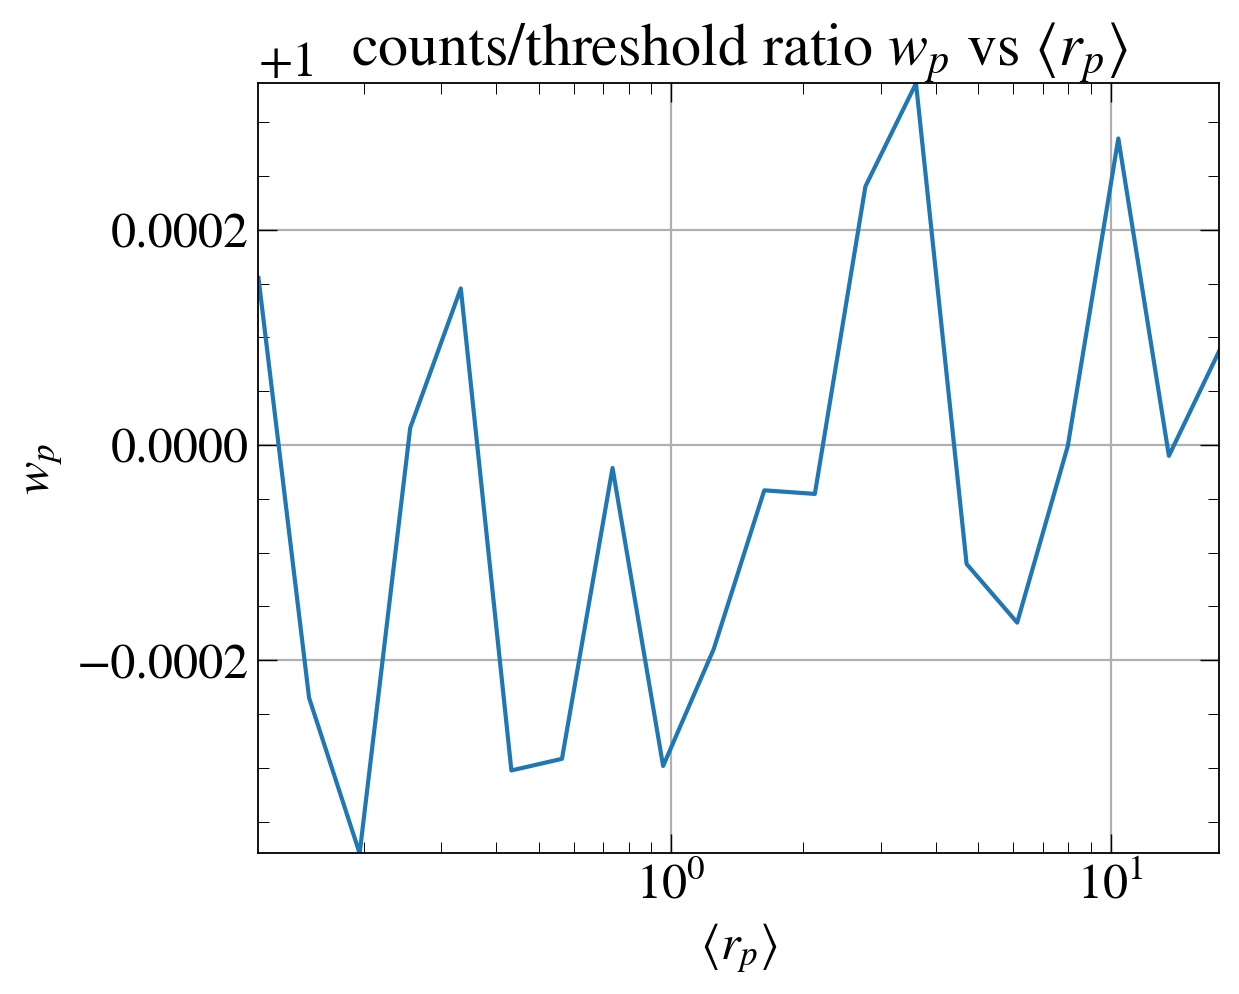

In [14]:
rpavg_counts, wp_counts, stdev_counts = ct.error_data(all_rp_counts, all_wp_counts)
rpavg_threshold, wp_threshold, stdev_threshold = ct.error_data(all_rp_thresh, all_wp_thresh)
rp = (np.array(rpavg_counts) + np.array(rpavg_threshold))/2
wp_ = []
for i in range(len(wp_counts)):
    print(wp_counts[i], wp_threshold[i], wp_counts[i]/wp_threshold[i])
    wp_.append(wp_counts[i]/wp_threshold[i])
plt.plot(rp, wp_)
plt.title(r'counts/threshold ratio $w_p$ vs $\langle r_p\rangle$')
plt.xlabel(r'$\langle r_p\rangle$')
plt.ylabel(r'$w_p$')
plt.xscale('log')